In [1]:
# import xgboost as xgb
# from xgboost import XGBRegressor
# print("Success! XGBoost is ready.")

In [2]:
# !pip install --upgrade xgboost scikit-learn

In [3]:
# # Remove the Anaconda version
# !conda remove --force xgboost -y

# # Remove any pip versions (run twice to be sure)
# !pip uninstall xgboost -y
# !pip uninstall xgboost -y

In [4]:
# !pip install xgboost

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

In [6]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [7]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
train_df.dtypes[train_df.dtypes != 'object']

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

In [9]:
# produce 38 numerical columns ( float64 and int64 )
train_df.describe() 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Plotting

1. Checking for outlier. See which houses have crazy expensive / cheap price than normal
- because MSSubClass is not linear, this feature is a good one to use to check for outlier and see which subclass has the highest cost


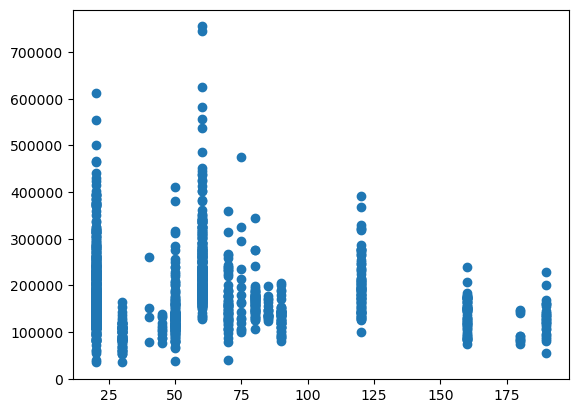

In [10]:
plt.scatter(train_df.MSSubClass, train_df.SalePrice)
# can also be written in plt.scatter(x='MSSubClass', y='train_df.SalePrice', data=train_df)


2. Checking the house width and price relation
- noticed few outliers such as the 2 dots on the right where house is so wide but priced so low

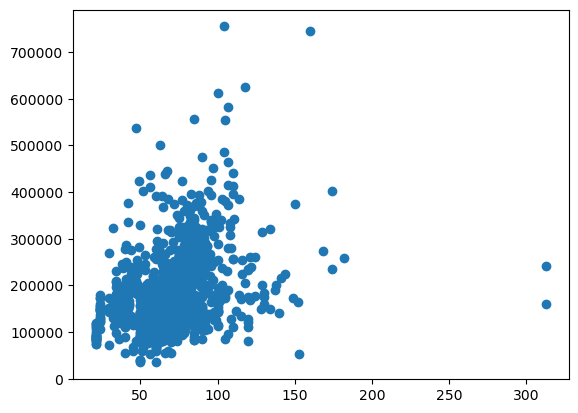

In [11]:
plt.scatter(train_df.LotFrontage, train_df.SalePrice)


- Get a desciption of those 2 outliers
- Drop them, because if they exist in Linear Regression, they will pull the line towards them when applying Gradient Descent
- If using Tree-based model / Gradient Boosting, it's fine to leave it

In [12]:
train_df.query('LotFrontage > 300')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


TODO: Drop 935, 1299

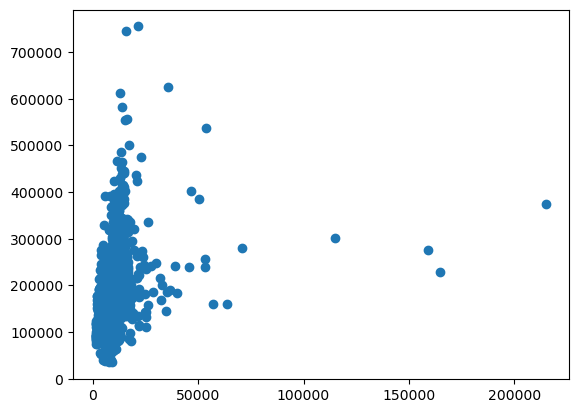

In [13]:
plt.scatter(train_df.LotArea, train_df.SalePrice)


Notice the outliers after 100000, drop them

In [14]:
train_df.query('LotArea > 50000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
53,54,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
384,385,60,RL,NaN,53107,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,240000
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
457,458,20,RL,NaN,53227,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,256000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
769,770,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


TODO: Drop 250, 314, 336, 707

Calculating Z- score
- To know how many standard deviations a specific data point is away from the average (mean) of the dataset
- Rule of thumb:
- Z > 2.0 : Unusual
- Z > 3.0 : Standard Outlier
- Z > 4.0 : Extreme Outlier

In [15]:
stats.zscore(train_df['LotArea']).sort_values()

956     -0.923729
1039    -0.905990
614     -0.904587
489     -0.901079
1449    -0.900377
          ...    
451      6.037793
706     10.486449
249     14.881285
335     15.448542
313     20.518273
Name: LotArea, Length: 1460, dtype: float64

Here we can confirm the outlier at index 313 which is id 314 has big standard deviation, which is why we need to drop them

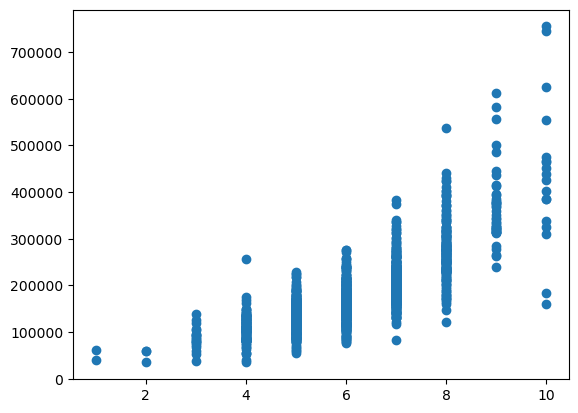

In [16]:
plt.scatter(train_df.OverallQual, train_df.SalePrice)


Overall Quality looks good overall with linear pattern, but noticed the 2 relatively cheap dots at 10
- Feel free to also check for other points that raise concerns or are suspicous

In [17]:
train_df.query('OverallQual == 10')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
224,225,20,RL,103.0,13472,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,386250
389,390,60,RL,96.0,12474,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2008,New,Partial,426000
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
515,516,20,RL,94.0,12220,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,New,Partial,402861
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
591,592,60,RL,97.0,13478,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,ConLI,Normal,451950
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


Notice we also made a note above to drop 1299, here we see that it has pool, big size, and relatively new but priced so slow.
- So we can confirm that it is a trouble maker,

TODO: Drop 524 (Maybe)

Extra
- Here shows a quick way to check for the 1 outlier where OverallQual = 4 by comparing it with the mean of other house with the same OverallQual

In [18]:
# Select the columns we care about for comparison
cols = ['SalePrice', 'GrLivArea', 'LotArea', 'YearBuilt']

# Define the specific outlier house using its index
weird_house = train_df.loc[[457]]

# Get the stats for the weird house
weird_stats = weird_house[cols]

# Get the average stats for ALL Quality 4 houses
avg_stats = train_df[train_df['OverallQual'] == 4][cols].mean()

# Combine them into one view for easy comparison
comparison = pd.concat([weird_stats.T, avg_stats], axis=1)
comparison.columns = ['Weird House (Index 457)', 'Average Quality 4 House']
print(comparison)

           Weird House (Index 457)  Average Quality 4 House
SalePrice                   256000            108420.655172
GrLivArea                     1663              1106.672414
LotArea                      53227              8917.982759
YearBuilt                     1954              1948.284483


As a result, we can see that, eventhough the SalePrice is higher, it is also newer than average, and GrLivArea is higher. which means this outlier is ok to stay

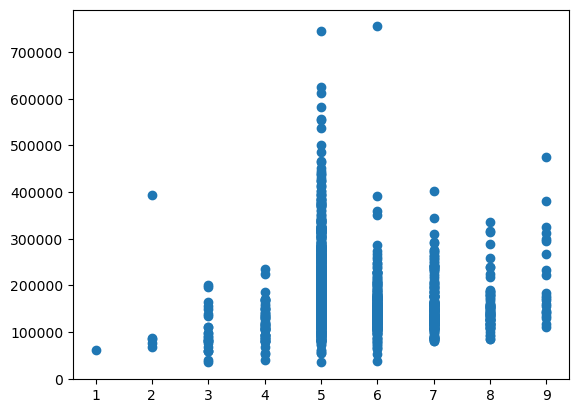

In [19]:
plt.scatter(train_df.OverallCond, train_df.SalePrice)

Notice the potential outlier at OverallCond at 2

In [20]:
train_df.query('OverallCond == 2')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
250,251,30,RL,55.0,5350,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,Shed,450,5,2010,WD,Normal,76500
378,379,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
398,399,30,RM,60.0,8967,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Abnorml,67000
676,677,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87000


Though 379 has higher LotArea, its SalePrice still should cost that much higher

TODO: 379 (maybe)

In [21]:
train_df.query('OverallCond == 5 & SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [22]:
train_df.query('OverallCond == 6 & SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


TODO: 1183, 692

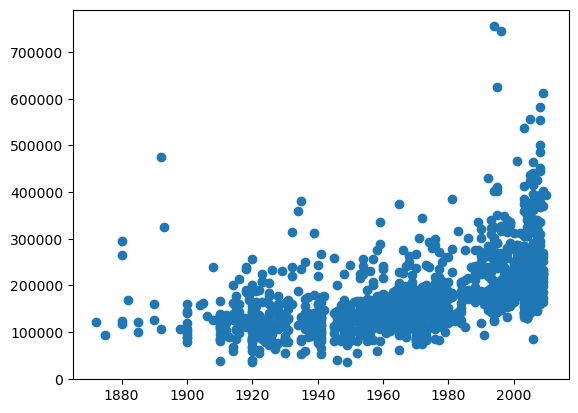

In [23]:
plt.scatter(train_df.YearBuilt, train_df.SalePrice)

In [24]:
# Find the one outlier
train_df.query('YearBuilt > 1880 & YearBuilt < 1900 & SalePrice > 400000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


TODO: 186

In [25]:
train_df.query('YearBuilt > 1980 & YearBuilt < 2000 & SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


Extra
- TODO: 692, 1183

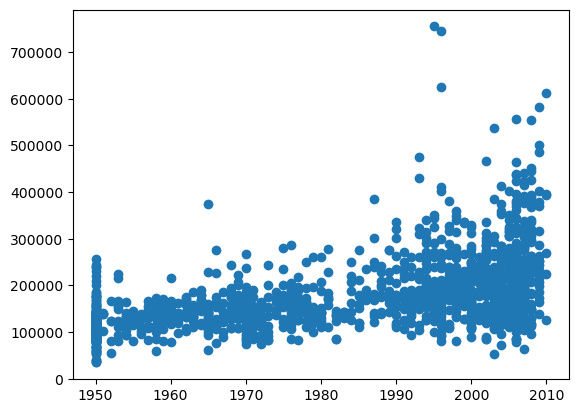

In [26]:
plt.scatter(train_df.YearRemodAdd, train_df.SalePrice)

In [27]:
train_df.query('YearRemodAdd > 1990 & YearRemodAdd < 2000 & SalePrice > 600000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


TODO: 1170
- 692 and 1183 already added to drop list when checking YearBuilt so we can skip here

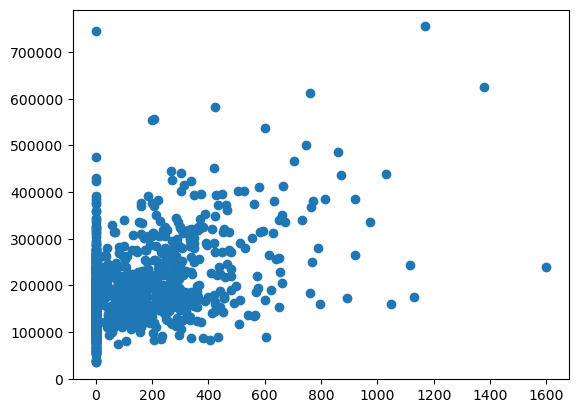

In [28]:
plt.scatter(train_df.MasVnrArea, train_df.SalePrice) # Total area of masonry veneer used in the house exterior

Noticed 2 strange outliers
- house priced the higest even though no vaneer was used
- house priced so low even though the most vaneer was used

In [29]:
train_df.query('MasVnrArea == 0 & SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [30]:
train_df.query('MasVnrArea == 1600 & SalePrice < 300000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
297,298,60,FV,66.0,7399,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,239000


TODO: Drop 298
- 1183 appears again here but it's been added to the drop list. This shows that it is another trouble maker

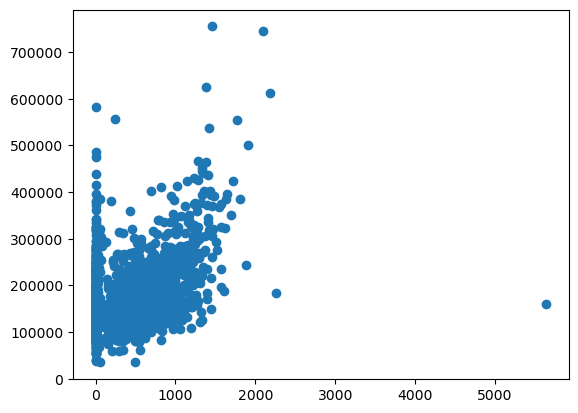

In [31]:
plt.scatter(train_df.BsmtFinSF1, train_df.SalePrice) #Basement Finished Square Feet (Type 1)

In [32]:
train_df.query('BsmtFinSF1 > 5000 & SalePrice < 300000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


1299 has been added to drop list when we checked LotFrontage. This proves another troublemaker

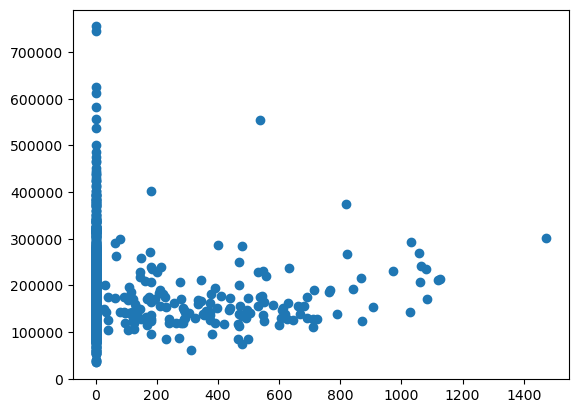

In [33]:
plt.scatter(train_df.BsmtFinSF2, train_df.SalePrice) #Basement Finished Square Feet (Type 2)

In [34]:
train_df.query('BsmtFinSF2 > 1400 & SalePrice < 320000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
322,323,60,RL,86.0,10380,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2007,WD,Normal,301000


In [35]:
train_df.query('BsmtFinSF2 > 400 & BsmtFinSF2 < 600 & SalePrice > 500000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000


In [36]:
train_df.query('BsmtFinSF2 == 0 & SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


TODO: Drop 323, 441
- 692 and 1183 already added to drop list when checking OverallCond

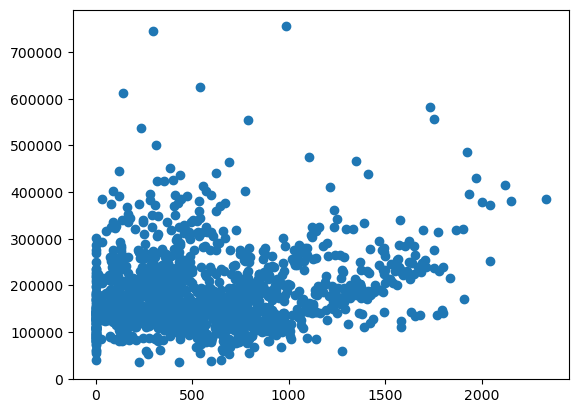

In [37]:
plt.scatter(train_df.BsmtUnfSF, train_df.SalePrice) #Basement Unfinished Square Feet

In [38]:
train_df.query('BsmtUnfSF > 200 & BsmtUnfSF < 1300 & SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


Troublemaker 692 and 1183 appear again so we can ignore since they have been added to the dorp list already

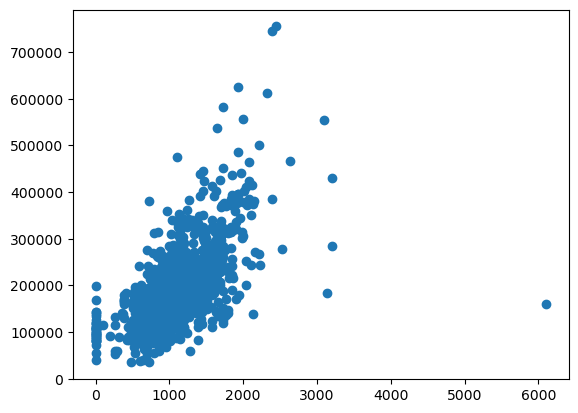

In [39]:
plt.scatter(train_df.TotalBsmtSF, train_df.SalePrice) #Total Basement Square Feet

In [40]:
train_df.query('TotalBsmtSF > 6000 & SalePrice > 100000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


Troublemaker 1299 appeared

Keep going through all other numerical features like:
- LowQualFinSF
- 1stFlrSF
- 2ndFlrSF
- GrLiveArea
- BsmtFullBath
- BsmtHalfBath
- FullBath
- BedroomAbvGr
- KitchenAbvGr
- TotRmsAbvGrc
- Fireplaces
- GarageYrBlt
- GarageArea
- WoiodDeckSF
- OpenPorchSF
- EnclosedPorch
- SsnPorch
- ScreenPorch
- PoolArea


In reality, 
- you dont need to go through every feature, but just check those with high impacts, those with high z-scores and those with missing data
- or just automate to generate all scatter plots at once

Dropping outliers

In [41]:
#  The ids of outliers
values = [598, 955, 935, 1299, 250, 314, 336, 707, 379, 1183, 692, 186, 441, 186, 524, 739, 598, 955, 636, 1062, 1191, 496, 198, 1338]

In [42]:
# Dropping rows with those ids using .isin()
train_df = train_df[train_df.Id.isin(values) == False]

Investigating Null values

NOTE: NaN doesnt mean it's empty data, check dataset documentation, most of the times if means NA for that specific feature
- Eg. feature 'Fence', NaN just means the house doesnt have a fence and we can replace 'NaN' with 'No' instead of removing it

In [43]:
# turn null column to True, count True as 1 and sum it up, arrange in descending order to see which feature as the most null values
pd.DataFrame(train_df.isnull().sum().sort_values(ascending=False)).head(20)

,0
PoolQC,1435
MiscFeature,1388
Alley,1350
Fence,1162
MasVnrType,861
FireplaceQu,684
LotFrontage,255
GarageYrBlt,76
GarageCond,76
GarageType,76


Dropping Columns with a lot of missing values, but remember to also make sure if check if the feature is high impact and whethere it will affect the saleprice alot

In [44]:
train_df['MiscFeature'].unique()

array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

Here we validate MiscFeature before straight up dropping it, we can see it holds Tennis Court (TenC) which doesnt impact much

Dealing with Null for 'Alley'

In [45]:
train_df['Alley'].unique()

array([nan, 'Grvl', 'Pave'], dtype=object)

For Alley, we can fill out nan as 'No' as no alley

In [46]:
train_df['Alley'].fillna('No', inplace=True)
test_df['Alley'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2277165759.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Alley'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2277165759.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [47]:
train_df['Alley'].unique()

array(['No', 'Grvl', 'Pave'], dtype=object)

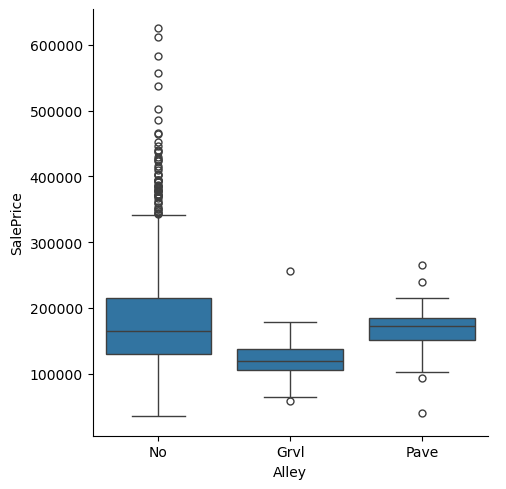

In [48]:
# Using box plot for Non-numberical variables. Alley in this case
sns.catplot(data=train_df, x="Alley", y="SalePrice", kind="box")

Low Impact
- We're using this box plot to see wheter alley has a lot of impact on the saleprice
- we see that this feature doesnt have much impact because houses with no alley and with pave valley have almost the same average price (the horizontal line in the blue box). This means there are other features that impact the salePrice more

In [49]:
# An example of how to get the count of each alley type
train_df.query('Alley == "Pave"').count()

Id               40
MSSubClass       40
MSZoning         40
LotFrontage      38
LotArea          40
                 ..
MoSold           40
YrSold           40
SaleType         40
SaleCondition    40
SalePrice        40
Length: 81, dtype: int64

Dealing with Null for 'Fence' by replacing 'nan' with 'No' to show no fence

In [50]:
train_df['Fence'].unique()

array([nan, 'MnPrv', 'GdWo', 'GdPrv', 'MnWw'], dtype=object)

In [51]:
train_df['Fence'].fillna('No', inplace=True)
test_df['Fence'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/3730986352.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Fence'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/3730986352.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

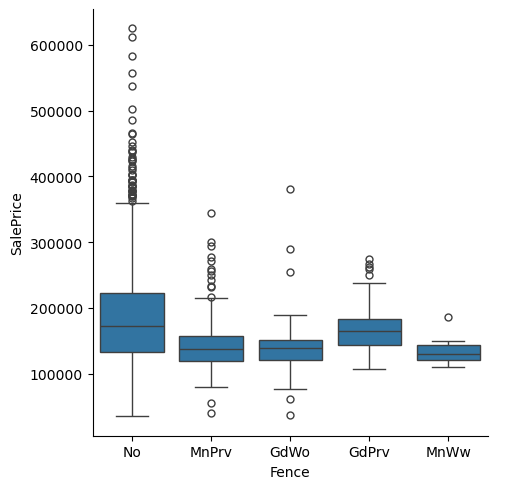

In [52]:
sns.catplot(data=train_df, x="Fence", y="SalePrice", kind="box")

Low impact
- Here we see hoses with No fence actually perform better than the ones with fence.


In [53]:
train_df['MasVnrType'].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [54]:
train_df['MasVnrType'].fillna('No', inplace=True)
test_df['MasVnrType'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2175816292.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['MasVnrType'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2175816292.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

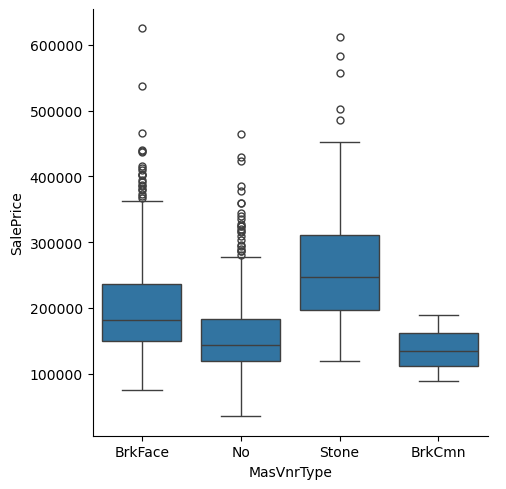

In [55]:
sns.catplot(data=train_df, x="MasVnrType", y="SalePrice", kind="box")

High Impact
- Here we can see MasVnrType is high impact, becuase houses with No vaneer are priced the lowest

In [56]:
# Setting null for MasVnrArea to 0
train_df['MasVnrArea'].fillna(0, inplace=True)
test_df['MasVnrArea'].fillna(0, inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2301248889.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['MasVnrArea'].fillna(0, inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2301248889.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [57]:
train_df['FireplaceQu'].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [58]:
train_df['FireplaceQu'].fillna('No', inplace=True)
test_df['FireplaceQu'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2825947256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['FireplaceQu'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2825947256.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

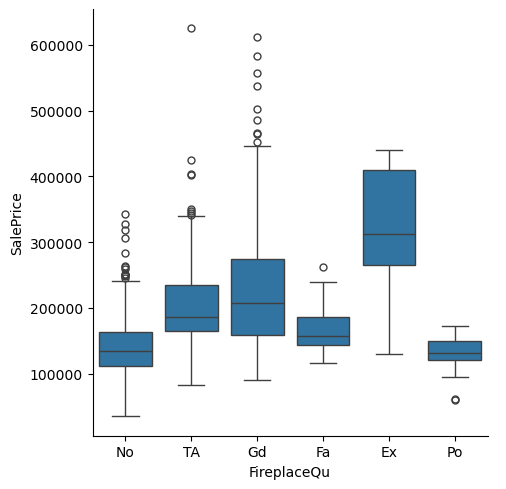

In [59]:
sns.catplot(data=train_df, x="FireplaceQu", y="SalePrice", kind="box")

High Impact
- we see how houses with no fireplace are worth less, and specific fireplace like Ex is worth more

In [60]:
train_df['LotFrontage'].unique()

array([ 65.,  80.,  68.,  60.,  84.,  85.,  75.,  nan,  51.,  50.,  70.,
        91.,  72.,  66., 101.,  57.,  44., 110.,  98.,  47., 108., 112.,
        74., 115.,  61.,  48.,  33.,  52., 100.,  24.,  89.,  63.,  76.,
        81.,  95.,  69.,  21.,  32.,  78., 121., 122.,  40., 105.,  73.,
        77.,  64.,  94.,  34.,  90.,  55.,  88.,  82.,  71., 120., 107.,
        92., 134.,  62.,  86., 141.,  97.,  54.,  41.,  79.,  99.,  67.,
        83.,  43., 103., 174.,  93.,  30., 129., 140.,  35.,  37., 118.,
        87., 116., 111.,  49.,  96.,  59.,  36.,  56., 102.,  58.,  38.,
       109., 130.,  53., 137.,  45., 106.,  42.,  39., 104., 144., 114.,
       128., 149., 168., 182., 138., 152., 124.,  46.])

In [61]:
train_df['LotFrontage'].fillna(0, inplace=True)
test_df['LotFrontage'].fillna(0, inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/1334701034.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['LotFrontage'].fillna(0, inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/1334701034.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [62]:
train_df['GarageYrBlt'].unique()

array([2003., 1976., 2001., 1998., 2000., 1993., 2004., 1973., 1931.,
       1939., 1965., 2005., 1962., 2006., 1960., 1991., 1970., 1967.,
       1958., 1930., 2002., 1968., 2007., 2008., 1957., 1920., 1966.,
       1959., 1995., 1954., 1953.,   nan, 1983., 1977., 1997., 1985.,
       1963., 1981., 1964., 1999., 1935., 1990., 1945., 1987., 1989.,
       1915., 1956., 1948., 1974., 2009., 1950., 1961., 1921., 1900.,
       1979., 1951., 1969., 1936., 1975., 1971., 1923., 1984., 1926.,
       1955., 1986., 1988., 1916., 1932., 1972., 1980., 1924., 1996.,
       1940., 1949., 1994., 1910., 1978., 1982., 1992., 1925., 1941.,
       1927., 1918., 1947., 1937., 1942., 1938., 1952., 1928., 1922.,
       1934., 1906., 1914., 2010., 1946., 1908., 1929., 1933.])

This GarageYrBlt might not be needed since we have YearBuilt and garage is mostly built the same year as house. 
- But below we check the corelation and the result is 0.82 which has high correlation which means YearBuilt basically repreasents GarageYrBlt and we can drop that feature

In [63]:
train_df['GarageYrBlt'].corr(train_df['YearBuilt'])


0.8289827595060572

In [64]:
train_df['GarageCond'].unique()

array(['TA', 'Fa', nan, 'Gd', 'Po', 'Ex'], dtype=object)

In [65]:
train_df['GarageCond'].fillna('No', inplace=True)
test_df['GarageCond'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/1255948083.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['GarageCond'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/1255948083.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

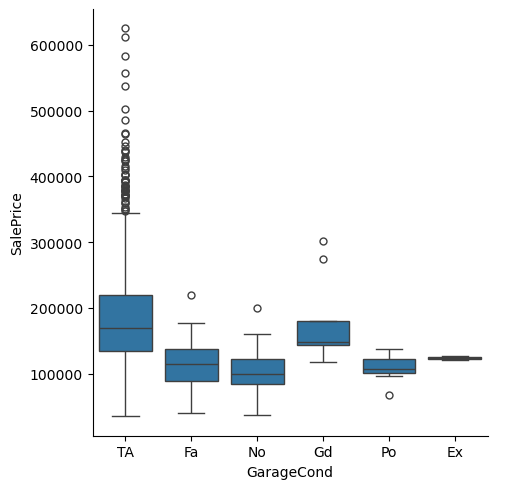

In [66]:
sns.catplot(data=train_df, x="GarageCond", y="SalePrice", kind="box")

Hight impact as expencted but not too high

In [67]:
train_df['GarageType'].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

In [68]:
train_df['GarageType'].fillna('No', inplace=True)
test_df['GarageType'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/3721453499.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['GarageType'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/3721453499.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

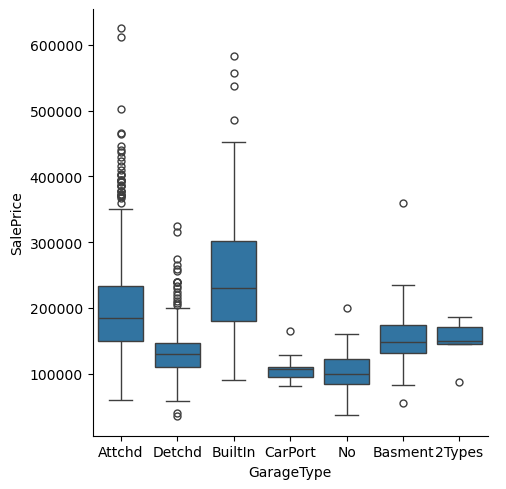

In [69]:
sns.catplot(data=train_df, x="GarageType", y="SalePrice", kind="box")

In [70]:
train_df['GarageFinish'].unique()

array(['RFn', 'Unf', 'Fin', nan], dtype=object)

In [71]:
train_df['GarageFinish'].fillna('No', inplace=True)
test_df['GarageFinish'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2912414829.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['GarageFinish'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2912414829.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

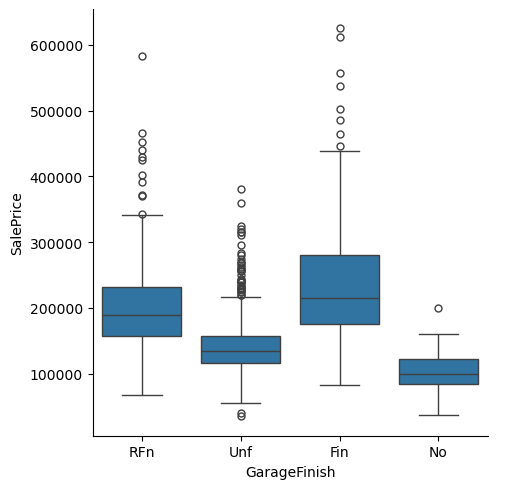

In [72]:
sns.catplot(data=train_df, x="GarageFinish", y="SalePrice", kind="box")

In [73]:
train_df['GarageQual'].unique()

array(['TA', 'Fa', 'Gd', nan, 'Po', 'Ex'], dtype=object)

In [74]:
train_df['GarageQual'].fillna('No', inplace=True)
test_df['GarageQual'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/94532614.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['GarageQual'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/94532614.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

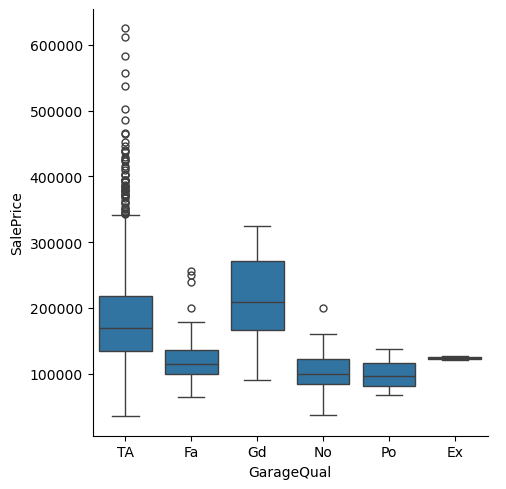

In [75]:
sns.catplot(data=train_df, x="GarageQual", y="SalePrice", kind="box")

In [76]:
train_df['BsmtFinType2'].unique()

array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [77]:
train_df['BsmtFinType2'].fillna('No', inplace=True)
test_df['BsmtFinType2'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/1264656746.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtFinType2'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/1264656746.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

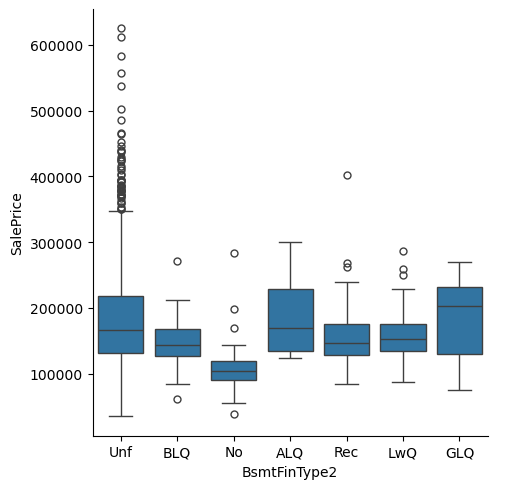

In [78]:
sns.catplot(data=train_df, x="BsmtFinType2", y="SalePrice", kind="box")

In [79]:
train_df['BsmtExposure'].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [80]:
train_df['BsmtExposure'].fillna('No', inplace=True)
test_df['BsmtExposure'].fillna('NO', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2077805979.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtExposure'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2077805979.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [81]:
train_df['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [82]:
train_df['BsmtQual'].fillna('No', inplace=True)
test_df['BsmtQual'].fillna('NO', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/3551777609.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtQual'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/3551777609.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

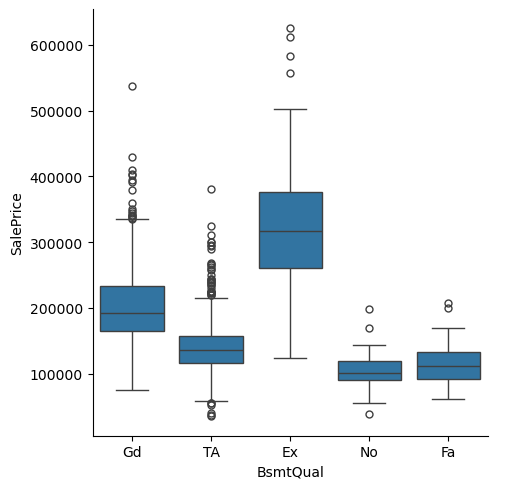

In [83]:
sns.catplot(data=train_df, x="BsmtQual", y="SalePrice", kind="box")

In [84]:
train_df['BsmtCond'].unique()

array(['TA', 'Gd', nan, 'Fa', 'Po'], dtype=object)

In [85]:
train_df['BsmtCond'].fillna('No', inplace=True)
test_df['BsmtCond'].fillna('NO', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/789357582.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtCond'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/789357582.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

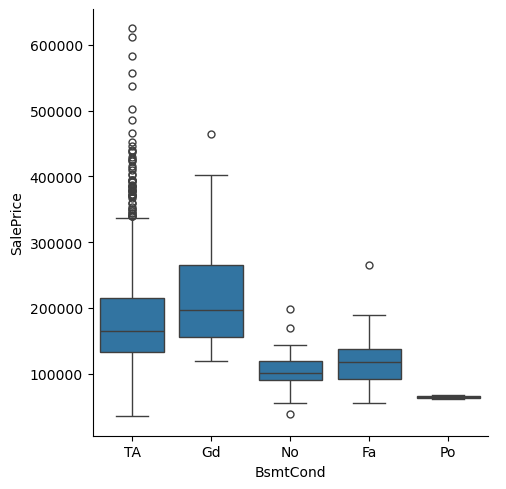

In [86]:
sns.catplot(data=train_df, x="BsmtCond", y="SalePrice", kind="box")

In [87]:
train_df['BsmtFinType1'].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

In [88]:
train_df['BsmtFinType1'].fillna('No', inplace=True)
test_df['BsmtFinType1'].fillna('No', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2898034224.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['BsmtFinType1'].fillna('No', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/2898034224.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

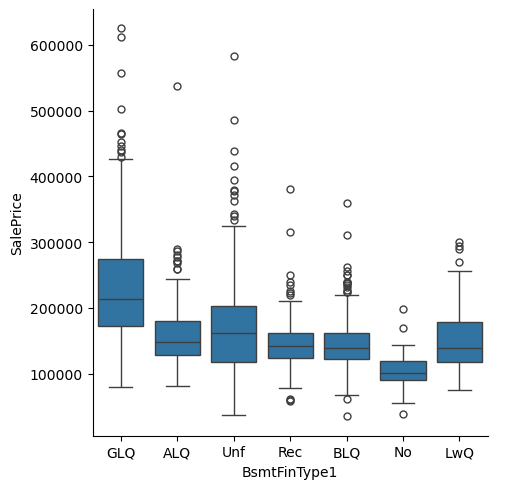

In [89]:
sns.catplot(data=train_df, x="BsmtFinType1", y="SalePrice", kind="box")

In [90]:
train_df['BsmtFinType1'].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', 'No', 'LwQ'], dtype=object)

In [91]:
train_df['Electrical'].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [92]:
train_df['Electrical'].fillna('SBrkr', inplace=True)
test_df['Electrical'].fillna('SBrkr', inplace=True)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/4245203846.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Electrical'].fillna('SBrkr', inplace=True)
/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/4245203846.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

NOTE: Here instead of replacing NaN with No, we replace with SBrkr as the document does explain waht NaN is and we dont want to drop it

In [93]:
# Dropping columns with low impact
train_df = train_df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2'])
test_df = test_df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'GarageYrBlt', 'GarageCond', 'BsmtFinType2'])

Feature Engineering

- Feature Aggregating
- Aggregating some columns and creating new columns

In [94]:
# aggregate houseage
train_df['houseage'] = train_df['YrSold'] - train_df['YearBuilt']
test_df['houseage'] = test_df['YrSold'] - test_df['YearBuilt']

In [95]:
train_df.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea',
       'GarageQual', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3Ssn

In [96]:
# aggregate houseremodleage
train_df['houseremodelage'] = train_df['YrSold'] - train_df['YearRemodAdd']
test_df['houseremodelage'] = test_df['YrSold'] - test_df['YearRemodAdd']

In [97]:
# create totalsf
train_df['totalsf'] = train_df['1stFlrSF'] + train_df['2ndFlrSF'] + train_df['BsmtFinSF1'] + train_df['BsmtFinSF2']
test_df['totalsf'] = test_df['1stFlrSF'] + test_df['2ndFlrSF'] + test_df['BsmtFinSF1'] + test_df['BsmtFinSF2']

In [98]:
# create totalarea
train_df['totalarea'] = train_df['GrLivArea'] + train_df['TotalBsmtSF']
test_df['totalarea'] = test_df['GrLivArea'] + test_df['TotalBsmtSF']

In [99]:
# create totalbaths
train_df['totalbaths'] = train_df['BsmtFullBath'] + train_df['FullBath'] + 0.5 * (train_df['BsmtHalfBath'] + train_df['HalfBath']) 
test_df['totalbaths'] = test_df['BsmtFullBath'] + test_df['FullBath'] + 0.5 * (test_df['BsmtHalfBath'] + test_df['HalfBath']) 

In [100]:
# create totalporchsf
train_df['totalporchsf'] = train_df['OpenPorchSF'] + train_df['3SsnPorch'] + train_df['EnclosedPorch'] + train_df['ScreenPorch'] + train_df['WoodDeckSF']
test_df['totalporchsf'] = test_df['OpenPorchSF'] + test_df['3SsnPorch'] + test_df['EnclosedPorch'] + test_df['ScreenPorch'] + test_df['WoodDeckSF']

After aggregating, we drop those that we dont need anymore

In [101]:
train_df = train_df.drop(columns=['Id','YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 'ScreenPorch','WoodDeckSF'])
test_df = test_df.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'GrLivArea', 'TotalBsmtSF','BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath', 'OpenPorchSF', '3SsnPorch', 'EnclosedPorch', 'ScreenPorch','WoodDeckSF'])

Plot heatmap to see correlation. check if there is anything that is redundant and we can drop them

<Axes: >

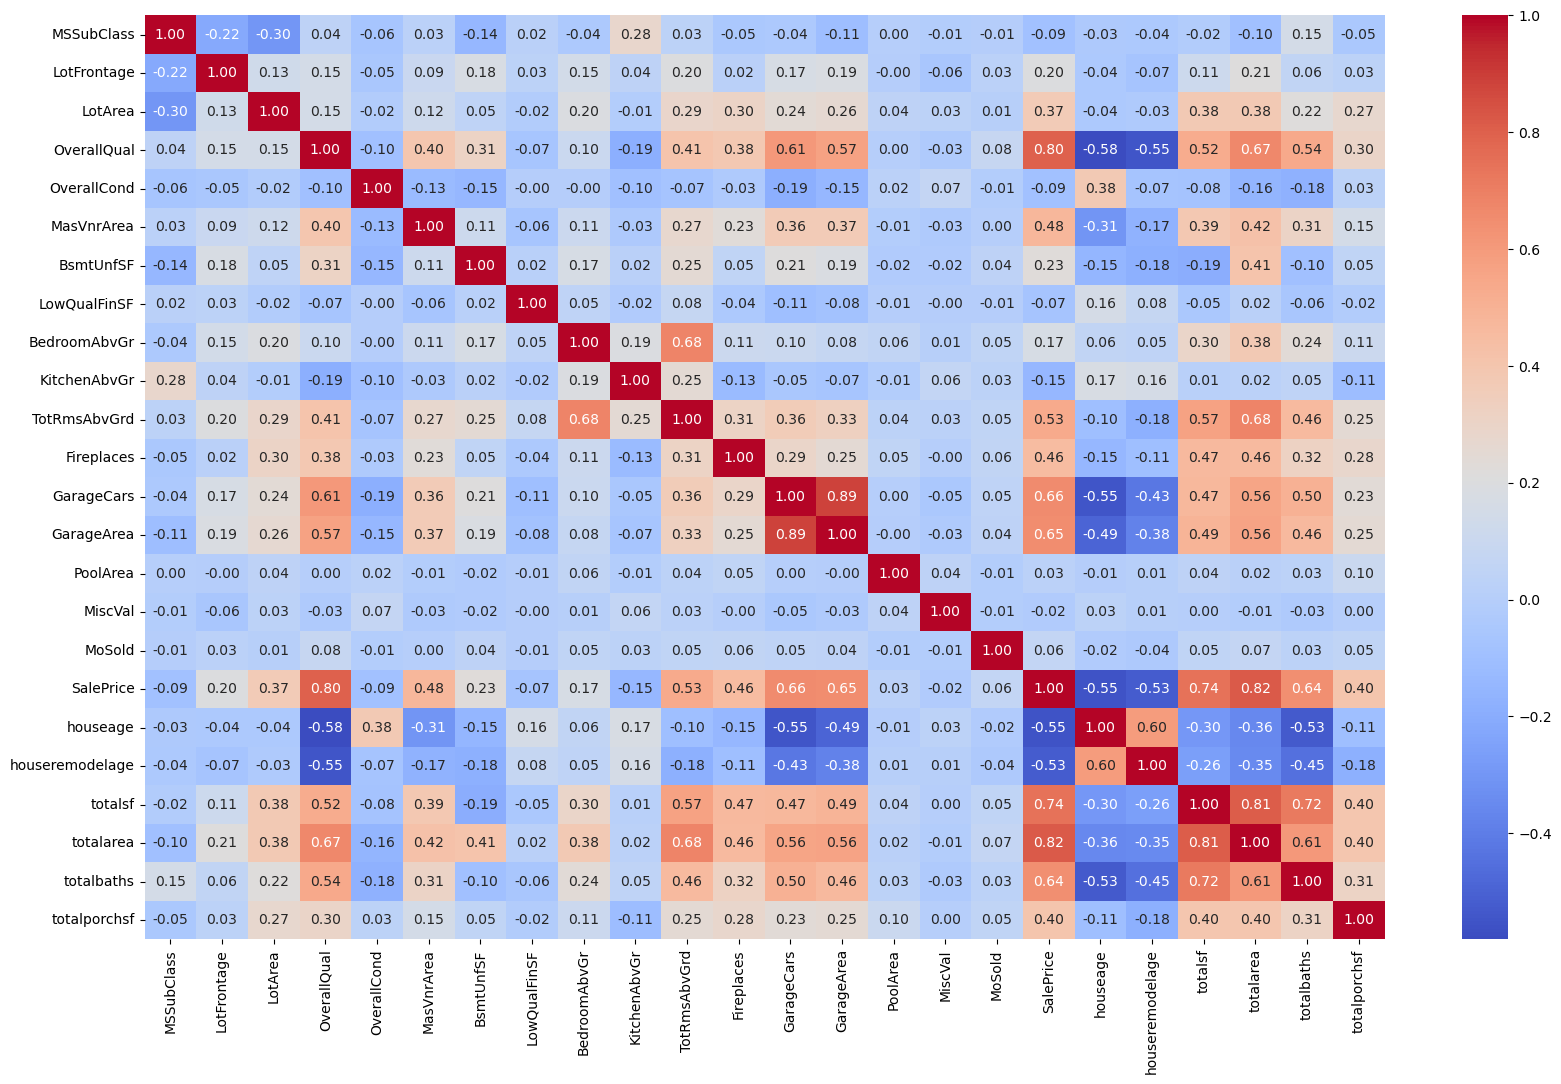

In [102]:
correlation_matrix = train_df.corr(numeric_only=True)
plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

Here we can see 'GarageCars' and 'GarageArea' has about the same correlation to target so there is redundancy. We will drop 'GarageArea' since it has less correlation with target of 0.65 where 'GarageCars' is 0.66

In [103]:
train_df = train_df.drop(columns=['GarageArea'])
test_df = test_df.drop(columns=['GarageArea'])

Now we check the histogram for skewness. In houseprice, the graph is likely to skew right because there will be few houses that are priced higher than normal.

<Axes: xlabel='SalePrice', ylabel='Count'>

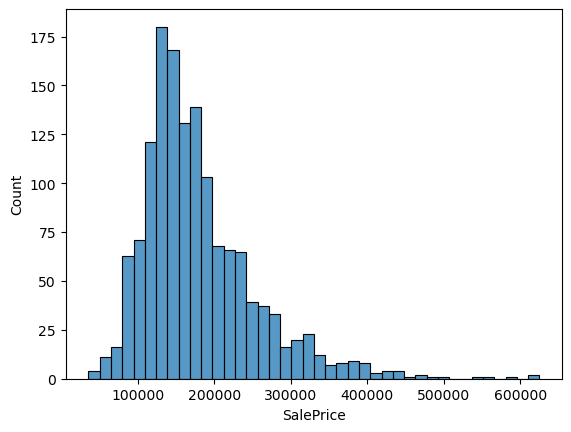

In [104]:
sns.histplot(
    train_df,
    x=train_df['SalePrice']
)

To solve this right skew issue, we apply log to the price


In [105]:
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

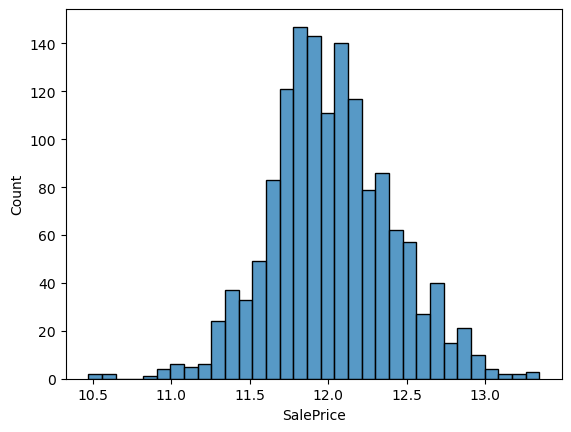

In [106]:
sns.histplot(
    train_df,
    x=train_df['SalePrice']
)

One Hot Encoding / Ordinal Encoding

Now we check the types of all objects and see which one is assign to OHE or ODE
- ODE - objects with different ranking so after encoded the one with higher rank will have higher number
- OHE - undordered objects 

In [107]:
train_df.dtypes[train_df.dtypes=='object']

MSZoning         object
Street           object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
PavedDrive       object
SaleType         object
SaleCondition    object
dtype: object

In [108]:
train_df.dtypes[train_df.dtypes !='object']

MSSubClass           int64
LotFrontage        float64
LotArea              int64
OverallQual          int64
OverallCond          int64
MasVnrArea         float64
BsmtUnfSF            int64
LowQualFinSF         int64
BedroomAbvGr         int64
KitchenAbvGr         int64
TotRmsAbvGrd         int64
Fireplaces           int64
GarageCars           int64
PoolArea             int64
MiscVal              int64
MoSold               int64
SalePrice          float64
houseage             int64
houseremodelage      int64
totalsf              int64
totalarea            int64
totalbaths         float64
totalporchsf         int64
dtype: object

In [109]:
ode_cols = ['LotShape', 'LandContour','Utilities','LandSlope',  'BsmtQual',  'BsmtFinType1',  'CentralAir',  'Functional', \
           'FireplaceQu', 'GarageFinish', 'GarageQual', 'PavedDrive', 'ExterCond', 'KitchenQual', 'BsmtExposure', 'HeatingQC','ExterQual', 'BsmtCond']

In [110]:
ohe_cols = ['Street', 'LotConfig','Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', \
           'MasVnrType','Foundation',  'Electrical',  'SaleType', 'MSZoning', 'SaleCondition', 'Heating', 'GarageType', 'RoofMatl']

In [111]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('SalePrice')

Here we fill up NaN value and apply standardization
- SimpleImputer: uses mean to fill every NaN value
- StandardScaler: aka Standardization. To turn numerical data by shifting the average to 0 and scaling the spread so that most values fall between -3 and 3, ensuring every feature has an equal impact on your model.

In [112]:
num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

NOTE: 
ODE is used to make the "higher ranking have a higher number," we need to pass a list of lists to the categories parameter in your OrdinalEncoder.
eg. 

# Define the order for your specific columns
# Low rank -> High rank
quality_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex'] 
finish_order = ['Unf', 'RFn', 'Fin']

# Update your pipeline
ode_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ode', OrdinalEncoder(
        # You must provide an order for EVERY column in ode_cols
        categories=[quality_order, quality_order, ...], 
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

In [113]:
ode_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [114]:
ohe_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Use 'ColumnTransformer' as traffic controller to direct specific columns to their designated "workstations":

- num_p: Sends your numerical columns to the num_pipeline (Imputing + Scaling).

- ode_p: Sends ordinal columns to the ode_pipeline (Imputing + Ordinal Encoding).

- ohe_p: Sends nominal columns to the ohe_pipeline (One-Hot Encoding).

- remainder='passthrough': If there are any columns you forgot to mention, it keeps them as-is instead of dropping them.

In [115]:
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipeline, num_cols),
    ('ode_p', ode_pipeline, ode_cols),
    ('ohe_p', ohe_pipeline, ohe_cols),
    ],
    remainder='passthrough', 
    n_jobs=-1)

Wrapping that traffic controller inside a Scikit-Learn Pipeline. This is best practice because it allows you to treat your entire preprocessing sequence as a single object. Later, you can simply add a model (like RandomForest) as a second step in this same pipeline.

In [116]:
pipeline = Pipeline(steps=[
    ('preprocessing', col_trans)
])

Separating target from features

In [117]:
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

Split data into 2 piles:
- Training set 80%
- Testing set 20%

In [118]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=25
)

This is where the magic happens. The pipeline looks at X, learns the necessary statistics (like the mean for imputer and the rank for the encoder), and then applies those changes to the data.
- After fitting, X_preprocessed is no longer a Pandas DataFrame; it is now a massive NumPy array of numbers.
- Note, train test split needs to be done before fit_transform to avoid Data leakage. Otherwise, the test set data will leak into your training set

1. fit_transform(X_train_raw)
- This is the "Studying" phase.

- Fit: The pipeline looks at the training data and calculates (learns) the statistics. It finds the mean for your numbers and the most_frequent categories for your objects.

- Transform: It then immediately applies those rules to the training data (e.g., filling in the gaps with the mean it just calculated).

2. transform(X_test_raw)
- This is the "Exam" phase.

- Transform Only: Here, we do not want the student to look at the exam answers to "learn" anything new. We want them to use the knowledge they already gained from the training data to process the test data.

- If you used fit_transform on the test set, the imputer would calculate a new mean based on the test houses. This would be "cheating" (Data Leakage) because in the real world, you won't have the "future" data to calculate averages with.

In [119]:
# 2. Fit and Transform the TRAINING data
# This calculates means/modes using ONLY the 80% training set
X_train = pipeline.fit_transform(X_train_raw)

# 3. Transform the TEST data 
# This uses the rules learned from the training set to prepare the test set
X_test = pipeline.transform(X_test_raw)

Build Models

1. Linear Regression

In [120]:
lr = LinearRegression()

In [121]:
lr.fit(X_train, y_train)

LinearRegression()

In [122]:
y_pred_lr = lr.predict(X_test)

In [123]:
mean_squared_error(y_test, y_pred_lr)

1.5106448817240645e+18

2. Random Forest

In [124]:
RFR = RandomForestRegressor(random_state=13)

In [125]:
# Hyperparameters
param_grid_RFR = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 250, 500],
    'min_samples_split': [3, 5, 10]
}

GridSearchCV is as 'automated experimenter' that automatically run the hyperparameters combination
- in our case, it will run 27 times becuase we have 3 max_depth x 3 n_estimators x 3 min_samples_split
- it will then compare and return the best hyperparameter combination 
- the main goal is to prevent Overfitting as if your max_depth is too high, the Random Forest will "memorize" your training data perfectly but fail on the test data. If it's too low, it won't learn enough.GridSearchCV finds the "sweet spot" where the model is complex enough to learn but simple enough to generalize to new houses.

In [126]:
rfr_cv = GridSearchCV(RFR, param_grid_RFR, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)


In [127]:
rfr_cv.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=13), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [3, 5, 10],
                         'n_estimators': [100, 250, 500]},
             scoring='neg_mean_squared_error')

In [128]:
np.sqrt(-1 * rfr_cv.best_score_)


0.13383339873228997

here we can check the best possible combination that GridSearchCV found

In [129]:
rfr_cv.best_params_

{'max_depth': 15, 'min_samples_split': 3, 'n_estimators': 500}

3. XGBoost

In [130]:

xgb_regression = XGBRegressor(random_state=13)


In [131]:
param_grid_XGB = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [300],
    'max_depth': [3],
    'min_child_weight': [1,2,3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
}

In [132]:
xgb_cv = GridSearchCV(xgb_regression, param_grid_XGB, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

In [133]:
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=13, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9, 1.0],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3],
                         'min_child_weight': [1, 2, 3], 'n_estimators': [300],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='neg_mean_squared_error')

In [134]:
np.sqrt(-1 * xgb_cv.best_score_)

0.11871798784728256

4. Ridge regression - a Linear Regression with a "safety belt" called Regularization
- In a normal Linear Regression, the model tries to fit the training data as perfectly as possible. However, if your data has many features (like your house dataset), the model can become too "aggressive" and overfit—essentially memorizing the noise in the training data rather than the actual patterns.

- Ridge Regression prevents this by adding a penalty to the size of the coefficients.

- The Penalty: If the model starts giving too much importance to a specific feature (like the number of windows), Ridge pulls that coefficient back toward zero.

- The Goal: It forces the model to stay simple and balanced, which usually helps it perform better on the X_test data it hasn't seen before.

In [135]:
ridge = Ridge()

1. alpha (The Strength)
This is the most important knob for Ridge.

Low Alpha (0.05): The "safety belt" is loose. It acts almost like normal Linear Regression.

High Alpha (10): The "safety belt" is very tight. It heavily restricts the coefficients to prevent overfitting.

GridSearchCV is testing all these values to find the "sweet spot."

2. solver
This is just the mathematical algorithm the computer uses to solve the equation.

svd and cholesky: Fast and accurate for most datasets.

sag and saga: (Stochastic Average Gradient) Better for very large datasets, but they can be picky.

In [136]:
param_grid_ridge = {
    'alpha': [0.05, 0.1, 1, 3, 5, 10],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag']
}

In [137]:
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [138]:
ridge_cv.fit(X_train, y_train)


/Users/lukecheng/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lukecheng/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lukecheng/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lukecheng/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lukecheng/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/lukecheng/anaconda3/lib/python3.11/sit

GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': [0.05, 0.1, 1, 3, 5, 10],
                         'solver': ['auto', 'svd', 'cholesky', 'lsqr',
                                    'sparse_cg', 'sag']},
             scoring='neg_mean_squared_error')

Why are you getting that ConvergenceWarning?
You see a warning in your image saying: The max_iter was reached which means the coef_ did not converge.

This is happening because of the sag solver. The "SAG" algorithm is an iterative process (it takes many small steps to find the best answer). It reached its limit of steps (usually 1,000) before it could finish finding the perfect "bottom of the hill."

How to fix the warning:

Increase iterations: Change your model to Ridge(max_iter=10000).

Scale your data: Ensure you are using StandardScaler (which you are doing in your num_pipeline).

Ignore it: For Ridge, the cholesky or svd solvers usually find the answer immediately. If GridSearchCV picks one of those as the "best solver," you can safely ignore the warning from the sag attempt.

In [139]:
np.sqrt(-1 * ridge_cv.best_score_)

0.10906292948679212

Note: here we can see it performs wors than linear regression even though ridge is made to handle many features. 
- Linear Regression: It will do whatever it takes to minimize the error on the training set, even if it means creating a complex formula that won't work on new data.

- Ridge: Because it has that "safety belt" (regularization), it intentionally accepts a slightly higher error on the training data to ensure it is more robust for the test data.

- To see the truth, you need to check the Test Score, not just the training score.

- If the Linear Regression RMSE jumps from 0.017 on Training to 0.25 on Test, but Ridge stays at 0.11 on both, then Ridge is actually the superior model.

5. Gradient Boosting Regressor

In [140]:
GBR = GradientBoostingRegressor()

In [141]:
param_grid_GBR = {
    'max_depth': [12, 15, 20],
    'n_estimators': [200, 300, 1000],
    'min_samples_leaf': [10, 25, 50],
    'learning_rate': [0.001, 0.01, 0.1],
    'max_features': [0.01, 0.1, 0.7]
}

In [142]:
GBR_cv = GridSearchCV(GBR, param_grid_GBR, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [143]:
GBR_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1],
                         'max_depth': [12, 15, 20],
                         'max_features': [0.01, 0.1, 0.7],
                         'min_samples_leaf': [10, 25, 50],
                         'n_estimators': [200, 300, 1000]},
             scoring='neg_mean_squared_error')

In [144]:
np.sqrt(-1 * GBR_cv.best_score_)

0.11327331247916332

6. LGBMRegressor (LightGBM)
- Developed by Microsoft, LightGBM stands for Light Gradient Boosting Machine. Its primary goal is speed and efficiency.

- Leaf-wise Growth: Unlike other models that grow trees level by level (balanced), LightGBM grows trees "leaf-wise." It picks the specific leaf that will reduce the most loss, which often leads to much higher accuracy.

- The "Light" Part: It is designed to be extremely fast and use lower memory. It is the go-to model for very large datasets where XGBoost might take too long to train.

- Performance: Your current RMSE is 0.1272, which is competitive with your other ensemble models.

In [145]:
lgbm_regressor = lgb.LGBMRegressor()

In [146]:
param_grid_lgbm = {
    'boosting_type': ['gbdt', 'dart'],
    'num_leaves': [20, 30, 40],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

In [147]:
lgbm_cv = GridSearchCV(lgbm_regressor, param_grid_lgbm, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

In [148]:
lgbm_cv.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070553 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1817
[LightGBM] [Info] Number of data points in the train set: 767, number of used features: 102
[LightGBM] [Info] Start training from score 12.032237
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1817
[LightGBM] [Info] Number of data points in the train set: 767, number of used features: 102
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info

GridSearchCV(cv=3, estimator=LGBMRegressor(), n_jobs=-1,
             param_grid={'boosting_type': ['gbdt', 'dart'],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'n_estimators': [100, 200, 300],
                         'num_leaves': [20, 30, 40]},
             scoring='neg_mean_squared_error')

In [149]:
np.sqrt(-1 * lgbm_cv.best_score_)

0.12740886862621015

7. CatBoostRegressor
- Developed by Yandex, CatBoost stands for Categorical Boosting. Its name gives away its specialty: handling categorical data.

- Native Categorical Support: Most models (like Ridge or XGBoost) require you to use OneHotEncoder or OrdinalEncoder first. CatBoost can handle categorical strings directly without any preprocessing, often producing better results because it uses a more advanced internal encoding method.

- Symmetry: It builds "symmetric trees," which makes it very fast at making predictions once the model is trained and helps prevent overfitting.

- Robustness: It is famous for working very well with "out-of-the-box" settings, meaning you often don't have to tune the hyperparameters as much as you do with XGBoost.

In [150]:
catboost = CatBoostRegressor(loss_function='RMSE', verbose=False)

In [151]:
param_grid_cat ={
    'iterations': [100, 500, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.5]
}

In [152]:
cat_cv = GridSearchCV(catboost, param_grid_cat, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

In [153]:
cat_cv.fit(X_train, y_train)

/Users/lukecheng/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=CatBoostRegressor(loss_function='RMSE', verbose=False),
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8, 10], 'iterations': [100, 500, 1000],
                         'learning_rate': [0.01, 0.05, 0.1, 0.5]},
             scoring='neg_mean_squared_error')

In [154]:
np.sqrt(-1 * cat_cv.best_score_)

0.11475569741494256

8. Voting Regressos
- An 'Ensemble' method, combine the predictions of multiple models (like your Ridge, GBR, and XGBoost) to produce a more stable and accurate final answer.

- How it works: If GBR predicts $200k, XGB predicts $210k, and Ridge predicts $190k, the Voting Regressor averages them to $200k.

- Weights: You can give more "voting power" to your best-performing models. In your code, you assigned weights of [2, 3, 1], meaning XGBoost has the most influence because it likely performed best during your cross-validation.

- Why use it: It smoothes out individual model errors. If one model "hallucinates" a price that is way too high, the other models pull the average back down to reality.

In [ ]:
vr = VotingRegressor([('gbr', GBR_cv.best_estimator_),
                      ('xgb_regression', xgb_cv.best_estimator_),
                      ('ridge', ridge_cv.best_estimator_)],
                    weights=[2,3,1])

In [156]:
vr.fit(X_train, y_train)

VotingRegressor(estimators=[('gbr',
                             GradientBoostingRegressor(learning_rate=0.01,
                                                       max_depth=20,
                                                       max_features=0.1,
                                                       min_samples_leaf=25,
                                                       n_estimators=1000)),
                            ('xgb_regression',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=F...
                                          interaction_constraints=None,
                                          learning_rate=0.05, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=3,
                                          max_leaves=None, min_child_weight=1,
                                          missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=300,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=13, ...)),
                            ('ridge', Ridge(alpha=10, solver='svd'))],
                weights=[2, 3, 1])

In [157]:
print(type(xgb_cv.best_estimator_))
print(getattr(xgb_cv.best_estimator_, "_estimator_type", "No type attribute found"))

<class 'xgboost.sklearn.XGBRegressor'>
regressor


In [158]:
y_pred_vr = vr.predict(X_test)

In [159]:
mean_squared_error(y_test, y_pred_vr, squared=False)

/Users/lukecheng/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


0.11934429677311026

9. Stacking Regressor

- A more 'intelligent' than voting regressor, it instead of just taking a simple average, it uses a Final Estimator (a "Meta-Model") to learn how to best combine the predictions.

- Level 0 (Base Models): All your models (GBR, XGB, Cat, LGB, RFR) make their initial predictions on the data.

- Level 1 (Meta-Model): A final model (in your case, you used your Voting Regressor as the final estimator) looks at those predictions and learns which model is most trustworthy for different types of houses.

- The Logic: It might learn that "XGBoost is always right for luxury houses, but Ridge is better for small cottages." It then adjusts the final output based on those lea

In [160]:
estimators = [
    ('gbr', GBR_cv.best_estimator_),
    ('xgb_regression', xgb_cv.best_estimator_),
    ('cat', cat_cv.best_estimator_),
    ('lgb', lgbm_cv.best_estimator_),
    ('rfr', rfr_cv.best_estimator_),
]

In [161]:
stackreg = StackingRegressor(
            estimators = estimators,
            final_estimator = vr
)

In [162]:
stackreg.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1995
[LightGBM] [Info] Number of data points in the train set: 1151, number of used features: 112
[LightGBM] [Info] Start training from score 12.023259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1897
[LightGBM] [Info] Number of data points in the train set: 920, number of used features: 106
[LightGBM] [Info] Start training from score 12.032469
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total B

StackingRegressor(estimators=[('gbr',
                               GradientBoostingRegressor(learning_rate=0.01,
                                                         max_depth=20,
                                                         max_features=0.1,
                                                         min_samples_leaf=25,
                                                         n_estimators=1000)),
                              ('xgb_regression',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical...
                                                                            interaction_constraints=None,
                                                                            learning_rate=0.05,
                                                                            max_bin=None,
                                                                            max_cat_threshold=None,
                                                                            max_cat_to_onehot=None,
                                                                            max_delta_step=None,
                                                                            max_depth=3,
                                                                            max_leaves=None,
                                                                            min_child_weight=1,
                                                                            missing=nan,
                                                                            monotone_constraints=None,
                                                                            multi_strategy=None,
                                                                            n_estimators=300,
                                                                            n_jobs=None,
                                                                            num_parallel_tree=None,
                                                                            random_state=13, ...)),
                                                              ('ridge',
                                                               Ridge(alpha=10,
                                                                     solver='svd'))],
                                                  weights=[2, 3, 1]))

In [163]:
y_pred_stack = stackreg.predict(X_test)

In [164]:
mean_squared_error(y_test, y_pred_stack, squared=False)

/Users/lukecheng/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


0.11893874315302513

Think of this final step as the production line where you actually use the machine you spent all that time building.

The 3-Step Process
Preparation (transform): You take the new, unseen houses from the test set and put them through the same "cleaning" process as the training houses. This ensures they are scaled and encoded exactly the same way so the model can understand them.

Prediction (predict): You feed those cleaned houses into your Stacking Regressor (your team of models). It gives you its best guess for the price of each house.

The "Un-log" (np.exp): Because you trained your model using the logarithm of the prices to make the math easier for the computer, your predictions come out as log numbers. You use np.exp() to convert them back into actual dollars that humans can understand.

What are the results?
The File: You are creating a CSV file named submission.csv.

The Columns: It has two columns: the house Id and your model's predicted SalePrice.

The Warning: That pink box is just Pandas being "talkative". It’s warning you that you are adding the SalePrice column to a slice of a dataframe, but it won't stop your file from being created correctly.

In [166]:
df_test_preprocess = pipeline.transform(test_df)

In [167]:
y_stacking = np.exp(stackreg.predict(df_test_preprocess))

df_y_stacking_out = test_df[['Id']]
df_y_stacking_out['SalePrice'] = y_stacking

df_y_stacking_out.to_csv('submission.csv', index=False)

/var/folders/4n/hd5b4m5950sbjp1cnswf_x4h0000gn/T/ipykernel_67643/176896153.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_y_stacking_out['SalePrice'] = y_stacking
